In [1]:
import time

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

import matplotlib.pyplot as plt

In [2]:
pt_model_path = "../dense.pt"
model = models.resnet18()
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load(pt_model_path))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# 評価関数 (正解率を返すように変更)
def accuracy_test(model, test_loader, device):
    model.eval()
    model = model.to(device)
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    print(f'正解率: {accuracy:.2f}%')

In [4]:
transform = transforms.Compose([transforms.Resize(224),
                                transforms.ToTensor(),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])   

testset = torchvision.datasets.CIFAR10(root="../data", train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=400, shuffle=False)

In [5]:
start = time.time()
accuracy_test(model, testloader, device)
print(time.time()-start)

正解率: 94.59%
13.874714136123657


In [6]:
def low_rank_recursively(module, rank):
    for name, child in module.named_children():
        if isinstance(child, nn.Conv2d):  # 注目している層が畳み込み層なら
            kernel_size = child.kernel_size
            in_channels = child.in_channels
            out_channels = child.out_channels
            has_bias = child.bias is not None
            W = child.weight.permute(0, 2, 1, 3).reshape(out_channels * kernel_size[0], in_channels * kernel_size[1])  # 4階テンソル(出力チャネル数, 入力チャネル数, カーネル高さ, カーネル幅)を(出力チャンネル数, カーネル高さ, 入力チャネル数, カーネル幅)にし、(出力チャネル数×カーネル高さ) × (入力チャネル数×カーネル幅)の行列に
            U, S, V = torch.svd(W)  # 特異値分解
            D = min(rank, min(W.shape))  # その層のランクを決める
            print(D)
            A = U[:, :D] @ torch.sqrt(torch.diag(S[:D]))
            B = torch.sqrt(torch.diag(S[:D])) @ V[:, :D].T
            ch1 = nn.Conv2d(in_channels, D, (1, kernel_size[1]), (1, child.stride[1]), (0, child.padding[1]), bias=False)   # 第1層
            ch2 = nn.Conv2d(D, child.out_channels, (kernel_size[0], 1), (child.stride[0], 1), (child.padding[0], 0), bias = has_bias) # 第2層
            ch1.weight.data = B.reshape((D, 1, in_channels, kernel_size[1])).permute(0, 2, 1, 3)  # 定理より得た重みの設定
            ch2.weight.data = A.reshape((out_channels, kernel_size[0], D, 1)).permute(0, 2, 1, 3)  # 定理より得た重みの設定
            if has_bias:
                ch2.bias.data = child.bias  # バイアスはch2に引き継ぐ
            setattr(module, name, nn.Sequential(ch1, ch2))  # もとの層をch1とch2を連結したSequentialモジュールに置き換え
        else:
            low_rank_recursively(child, rank)  # 再帰的に探索(Sequential内のconvを見つけるため)

In [7]:
low_rank_recursively(model, rank=100)

start = time.time()
accuracy_test(model, testloader, device)
print(time.time()-start)

21
100
100
100
100
100
100
64
100
100
100
100
100
100
100
100
100
100
100
100
正解率: 80.71%
13.019250392913818


In [8]:
# 再訓練
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)
num_epochs = 10
epoch_loss_list = []
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0)
trainset = torchvision.datasets.CIFAR10(root = "../data", train = True, download = True, transform = transform)
trainloader = DataLoader(trainset, batch_size = 200, shuffle = True)

for epoch in range(num_epochs):
    model.train()
    model = model.to(device)
    total_loss = 0.0
    num_train = 0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()*labels.size(0)
        num_train += labels.size(0)

    epoch_loss_list.append(total_loss/num_train)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch[{epoch+1}/{num_epochs}], Loss: {epoch_loss_list[epoch]:.4f}, LR: {current_lr:.8f}')

    if epoch >= 1:
        if np.abs(epoch_loss_list[epoch]-epoch_loss_list[epoch-1]) < 0.001:
            print('early stop')
            break
    scheduler.step()

Epoch[1/10], Loss: 0.4062, LR: 0.00100000
Epoch[2/10], Loss: 0.2478, LR: 0.00097553
Epoch[3/10], Loss: 0.1769, LR: 0.00090451
Epoch[4/10], Loss: 0.1173, LR: 0.00079389
Epoch[5/10], Loss: 0.0704, LR: 0.00065451
Epoch[6/10], Loss: 0.0310, LR: 0.00050000
Epoch[7/10], Loss: 0.0089, LR: 0.00034549
Epoch[8/10], Loss: 0.0020, LR: 0.00020611
Epoch[9/10], Loss: 0.0009, LR: 0.00009549
Epoch[10/10], Loss: 0.0007, LR: 0.00002447
early stop


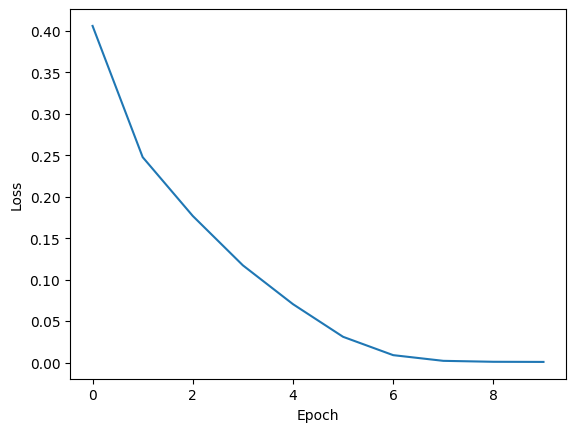

In [9]:
plt.plot(epoch_loss_list)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [10]:
start = time.time()
accuracy_test(model, testloader, device)
print(time.time()-start)

正解率: 95.13%
13.867722511291504
